# NNDL LAB 4
#### **Name: Shashank Goel**
#### **Batch: B.Tech Data Science**
#### **Roll no: J011**
#### **SAP ID: 70092300008**

## Exponentially Weighted Average

V100 = beta * V99 + (1- beta ) *  T99

V99 = beta * V98 + (1- beta) * T98

Higher the beta more the smoothness

Suppose beta = 0.9
 
V100 = 0.1 * T100 + 0.1 * 0.9 *  T99  + 0.1 * (0.9)^2 * T98

Easy way to calculate is 1/ ( 1- beta)


There is still an **issue** with this approach:
- V0 = 0 since no previous value is present
- V1 becomes 0 + 0.1 * T1

So due to this it would not be able to find the proper values for the starting values.
Therefore we need a bias correction for the smaller values.

## Bias Correction

**Bias correction: Vt = Vt / (1- beta ^ t)**

- When t is small, it corrects highly.
- When t is big, correction is negligible.

V2 = 1 / (1- 0.9^2) = 10

## Momentum 

**Momentum**

V = beta * v + (1- beta) dw

W = W - alpha * V

where v is weighted gradient

More noisy towards the ffradient descent means the model is more suspectible towards going in the wrong direction.

Problem: It can overshoot but it doesn't know to stop in the local minima.

## RMSprop (Root mean squre error prop)

RMSprop does rms upon the weights of the ANN to slow the model. This is a completely opposite approach compared to Momentum

RMSprop penalizes big / large gradients.

The aim is to take slow steps.

You can use a large learning rate as it is going to slow it doen

s = beta * s  + (1- beta) * (dW ^2)

W = W - alpha * (dW / (root(s) + epsilon ))

## Adam = Momentum + RMSprop

Adam is a combination of both the algorithm.

W = W - alpha * (v vector/ (root(s vector) + epsilon ))

Epsilon is small error term

# Learning rate decay

Slows down the learning rate as we go towards the minima and the momentum of the the optimizer doesn't make it skip the minima.

alpha  = alpha0 / (1 + decay * epoch)

In [1]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" # Suppress TensorFlow logging (1)

In [2]:
[(X_train_raw, y_train), (X_test_raw, y_test)] = keras.datasets.fashion_mnist.load_data()

In [3]:
print("X_train shape:", X_train_raw.shape)
print("X_test shape:", X_test_raw.shape)
X_train = (X_train_raw / 255.0).astype(np.float32)
X_test = (X_test_raw / 255.0).astype(np.float32)

X_train = X_train[:2000]
X_test = X_test[:200]

y_train = y_train[:2000]
y_test = y_test[:200]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)
X_train shape: (2000, 28, 28)
X_test shape: (200, 28, 28)
y_train shape: (2000,)
y_test shape: (200,)


In [4]:
def create_model():
    model = keras.models.Sequential([
        keras.layers.Flatten(input_shape = [28, 28]),
        keras.layers.Dense(300, activation= "relu"),
        keras.layers.Dense(100, activation= "relu"),
        keras.layers.Dense(10, activation= "softmax"),
    ])

    return model

curves = {}

def train_model(name, model, X, epochs= 10, callback = None, batch_size = 64, verbose = 0, optimiser = 'adam'):

    print(f"Training {name} for {epochs} epochs")

    model.compile(optimizer= optimiser, 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    
    history = model.fit(X, y_train, 
                    validation_split= 0.1, 
                    epochs = epochs, 
                    batch_size = batch_size, 
                    verbose=verbose, 
                    callbacks = callback)
    
    curves[name] = history.history["loss"]
    print(f"\n{name} final loss: {history.history['loss'][-1]:.4f}, final accuracy: {history.history['accuracy'][-1]:.4f}")

    train_acc = history.history['accuracy'][-1]
    test_acc = history.history['val_accuracy'][-1]
    
    print(f'Training Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}')

    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Test Loss')
    plt.title('Training and Test Loss')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()

    return history


#### Raw pixels

c:\Users\Shashank Goel\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Training Raw_pixels_sgd for 100 epochs
Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1006 - loss: 101694980096.0000 - val_accuracy: 0.1100 - val_loss: 2.3023
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1056 - loss: 2.3025 - val_accuracy: 0.1100 - val_loss: 2.3022
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1006 - loss: 2.3024 - val_accuracy: 0.1100 - val_loss: 2.3022
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1056 - loss: 2.3024 - val_accuracy: 0.1100 - val_loss: 2.3021
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1033 - loss: 2.3023 - val_accuracy: 0.1100 - val_loss: 2.3020
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1028 - loss: 2.3022 - val_accuracy: 0.1100 - val_loss: 2.3020
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1039 - loss: 2.3022 - val_accuracy: 0.1100 - val_loss: 2.3019
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

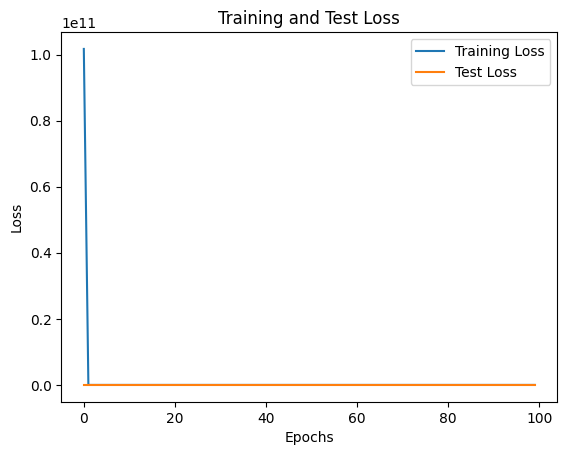

In [5]:
model = create_model()
model.summary()
train_model("Raw_pixels_sgd", model, X_train_raw[:2000], 
            epochs= 100, verbose= 1, batch_size = 32, optimiser = 'sgd')

#### Normalized pixels (Optimizer - SGD (Stochastic Gradient Descent))

Training Normalized_pixels_sgd for 100 epochs

Normalized_pixels_sgd final loss: 0.1687, final accuracy: 0.9539
Training Accuracy: 0.9539, Test Accuracy: 0.8200


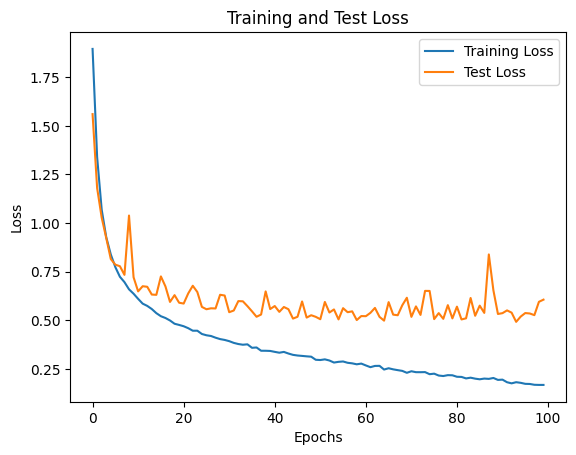

In [6]:
model_1 = create_model()
train_model("Normalized_pixels_sgd", model_1, X_train, 
            epochs= 100, verbose= 0,
            batch_size = 32, optimiser = 'sgd')

#### Full batch training

Training Full_batch_train for 100 epochs

Full_batch_train final loss: 1.2436, final accuracy: 0.6700
Training Accuracy: 0.6700, Test Accuracy: 0.6600


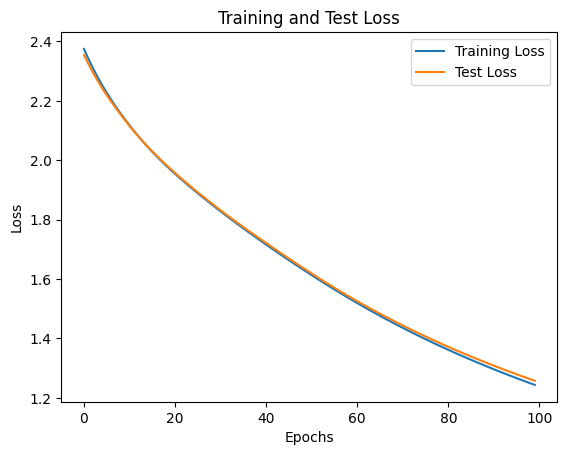

In [7]:
model_2 = create_model()
train_model("Full_batch_train", model_2, X_train, 
            epochs= 100, verbose= 0, 
            batch_size = 2000, optimiser = 'sgd')

#### Mini-batch training

Training Mini-batch (64) for 100 epochs

Mini-batch (64) final loss: 0.2659, final accuracy: 0.9194
Training Accuracy: 0.9194, Test Accuracy: 0.8150


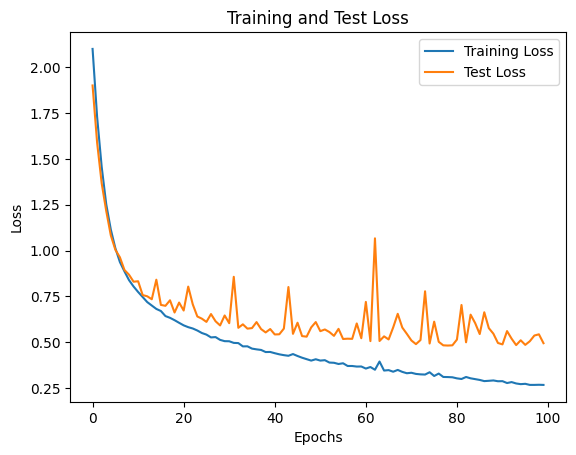

In [8]:
model_3 = create_model()
train_model("Mini-batch (64)", model_3, X_train, 
            epochs= 100, verbose= 0,
            batch_size = 64, optimiser = 'sgd')

#### Stochastic batch training

Training Stochastic batch training (1) for 100 epochs

Stochastic batch training (1) final loss: 0.0013, final accuracy: 0.9994
Training Accuracy: 0.9994, Test Accuracy: 0.8450


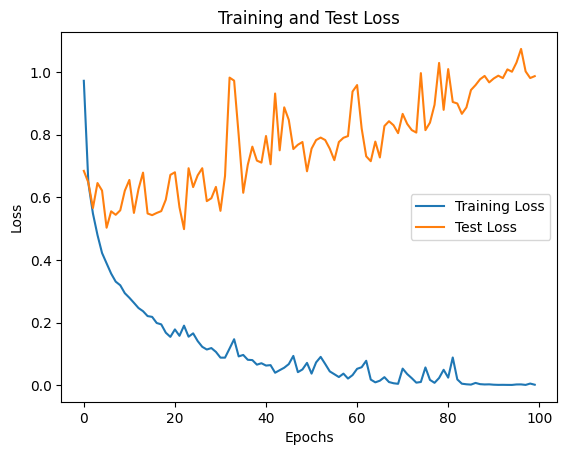

In [9]:
model_4 = create_model()
train_model("Stochastic batch training (1)", model_4, X_train, 
            epochs= 100, verbose= 0,
            batch_size = 1, optimiser = 'sgd')

c:\Users\Shashank Goel\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


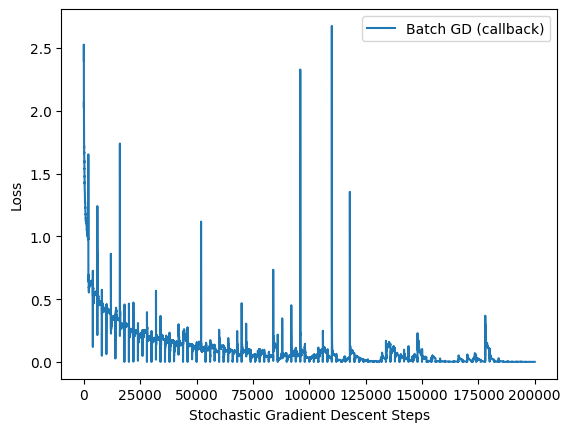

In [10]:
class Record(keras.callbacks.Callback):

    def __init__(self):
        self.losses = []
        self.accuracies = []
        self.val_losses = []
        self.val_accuracies = []

    def on_train_batch_end(self, epoch, logs):
        self.losses.append(logs['loss'])
        self.accuracies.append(logs['accuracy'])

recorder = Record()
model_5 = create_model()
model_5.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model_5.fit(X_train, y_train, epochs= 100, batch_size = 1, verbose=0, callbacks=[recorder])

plt.plot(recorder.losses, label='Batch GD (callback)')
plt.xlabel('Stochastic Gradient Descent Steps')
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Momentum

c:\Users\Shashank Goel\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Momentum (0.9) for 100 epochs

Momentum (0.9) final loss: 0.0068, final accuracy: 1.0000
Training Accuracy: 1.0000, Test Accuracy: 0.8300


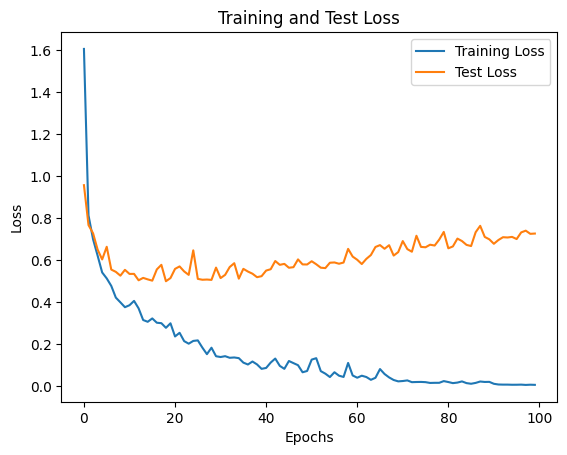

In [11]:
model_6 = create_model()
train_model("Momentum (0.9)", model_6, X_train, 
            epochs= 100, batch_size = 64, 
            optimiser = keras.optimizers.SGD(momentum=0.9), 
            verbose=0)

Training Momentum (0.1) for 100 epochs


c:\Users\Shashank Goel\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Momentum (0.1) final loss: 0.2464, final accuracy: 0.9300
Training Accuracy: 0.9300, Test Accuracy: 0.8100


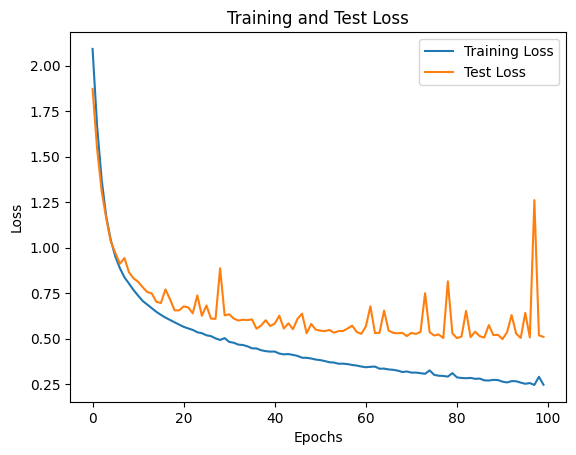

In [12]:
# Momentum
model_7 = create_model()

train_model("Momentum (0.1)", model_7, X_train, 
            epochs= 100, batch_size = 64, 
            optimiser = keras.optimizers.SGD(momentum=0.1), 
            verbose=0)

Training Momentum (0.5) for 100 epochs

Momentum (0.5) final loss: 0.1610, final accuracy: 0.9567
Training Accuracy: 0.9567, Test Accuracy: 0.8150


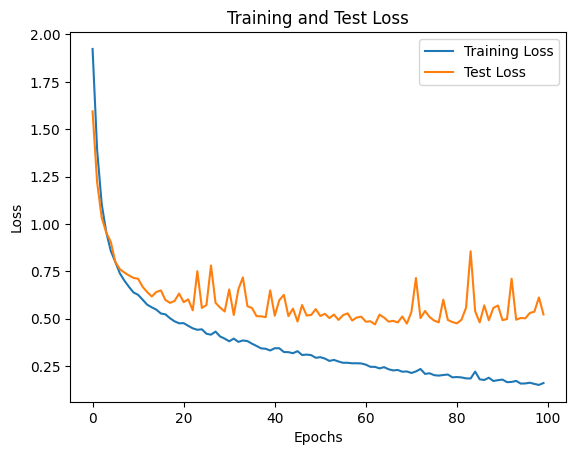

In [13]:
# Momentum
model_8 = create_model()
train_model("Momentum (0.5)", model_8, X_train, 
            epochs= 100, batch_size = 64, 
            optimiser = keras.optimizers.SGD(momentum=0.5), 
            verbose=0)

Training Momentum (1.0) for 100 epochs

Momentum (1.0) final loss: 3.0832, final accuracy: 0.0950
Training Accuracy: 0.0950, Test Accuracy: 0.0750


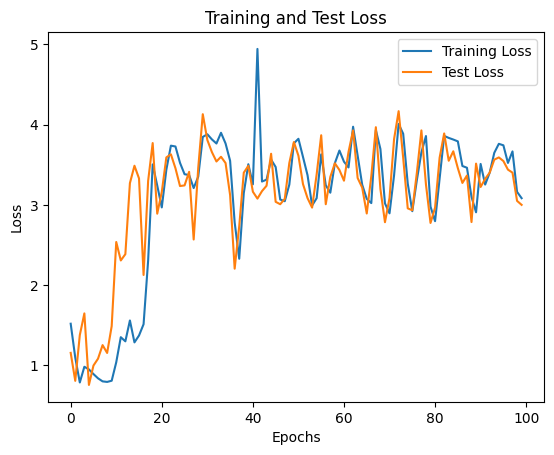

In [14]:
# Momentum
model_9 = create_model()
train_model("Momentum (1.0)", model_9, X_train, 
            epochs= 100, batch_size = 64, 
            optimiser = keras.optimizers.SGD(momentum=1.0), 
            verbose=0)

#### RMSprop

Training RMSprop (0.001) for 100 epochs

RMSprop (0.001) final loss: 0.0110, final accuracy: 0.9989
Training Accuracy: 0.9989, Test Accuracy: 0.8600


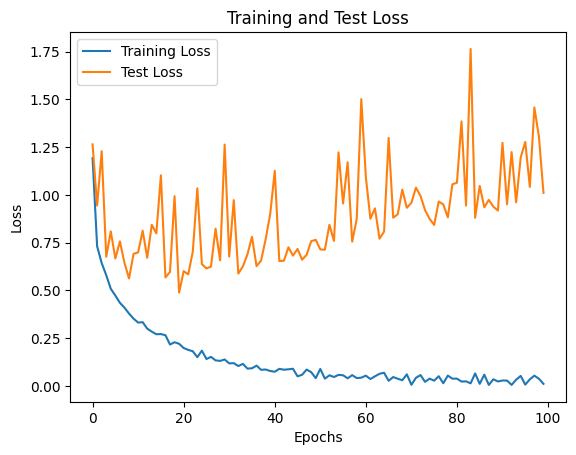

In [15]:
# RMSprop
model_10 = create_model()
train_model("RMSprop (0.001)", model_10, X_train, 
            epochs= 100, batch_size = 64, 
            optimiser = keras.optimizers.RMSprop(learning_rate=0.001), 
            verbose=0)

Training RMSprop (0.1) for 100 epochs

RMSprop (0.1) final loss: 2.3139, final accuracy: 0.0906
Training Accuracy: 0.0906, Test Accuracy: 0.1100


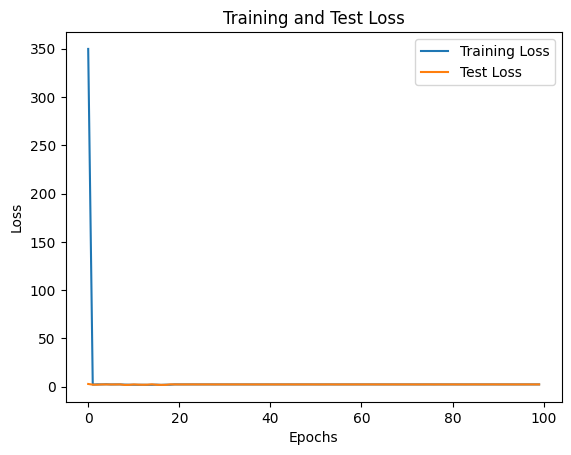

In [16]:
# RMSprop
model_11 = create_model()
train_model("RMSprop (0.1)", model_11, X_train, 
            epochs= 100, batch_size = 64, 
            optimiser = keras.optimizers.RMSprop(learning_rate=0.1), 
            verbose=0)

#### Adam

Training Adam (0.001) for 100 epochs

Adam (0.001) final loss: 0.0544, final accuracy: 0.9828
Training Accuracy: 0.9828, Test Accuracy: 0.8700


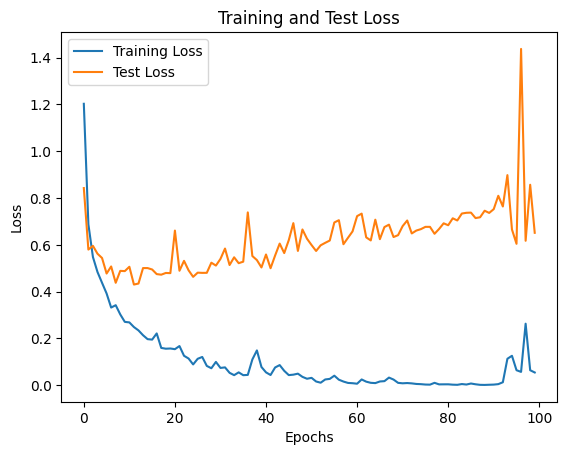

In [17]:
model_12 = create_model()
train_model("Adam (0.001)", model_12, X_train, 
            epochs= 100, batch_size = 64, 
            optimiser = keras.optimizers.Adam(learning_rate=0.001), 
            verbose=0)

#### Learning Rate Decay

c:\Users\Shashank Goel\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Learning Rate Decay for 100 epochs

Learning Rate Decay final loss: 0.1065, final accuracy: 0.9783
Training Accuracy: 0.9783, Test Accuracy: 0.8600


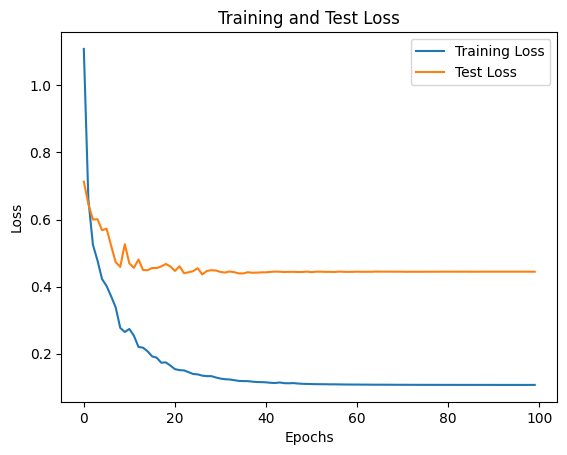

In [18]:
# Learning rate decay
def lr_schedule(epoch, lr):
    if epoch < 5:
        return lr
    else:
        return np.float32(lr * tf.math.exp(-0.1))

decay_callback = keras.callbacks.LearningRateScheduler(lr_schedule)

model_13 = create_model()
train_model("Learning Rate Decay", model_13, X_train, 
            epochs= 100, batch_size= 64, 
            optimiser= keras.optimizers.Adam(learning_rate=0.001), 
            verbose=0, callback= decay_callback)

In [19]:
curves

{'Raw_pixels_sgd': [101694980096.0,
  2.302466869354248,
  2.302403450012207,
  2.3023500442504883,
  2.302288293838501,
  2.302241802215576,
  2.3021910190582275,
  2.302156925201416,
  2.3021273612976074,
  2.3021047115325928,
  2.302062511444092,
  2.302063226699829,
  2.3020453453063965,
  2.3020129203796387,
  2.3020105361938477,
  2.301983118057251,
  2.3019797801971436,
  2.3019609451293945,
  2.301940679550171,
  2.3019309043884277,
  2.3019111156463623,
  2.3019137382507324,
  2.301917552947998,
  2.3018956184387207,
  2.3018929958343506,
  2.3018856048583984,
  2.301893711090088,
  2.301882028579712,
  2.301870822906494,
  2.3018593788146973,
  2.3018834590911865,
  2.3018877506256104,
  2.3018617630004883,
  2.301880359649658,
  2.301881790161133,
  2.3018786907196045,
  2.301877975463867,
  2.301868200302124,
  2.301856517791748,
  2.3018693923950195,
  2.3018791675567627,
  2.3018531799316406,
  2.301866292953491,
  2.3018720149993896,
  2.3018622398376465,
  2.30186295509

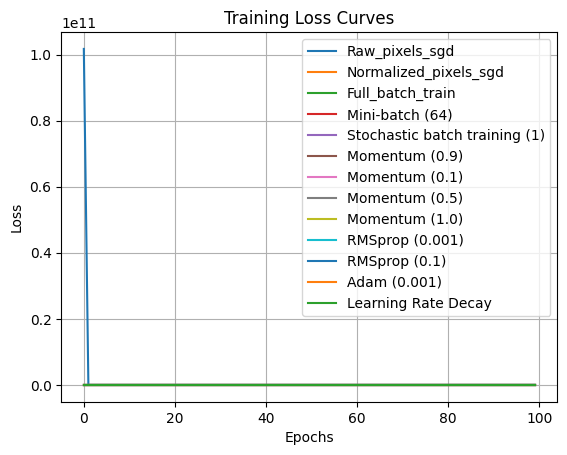

In [33]:
for name in curves:
    plt.plot(curves[name], label=name)
plt.title('Training Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

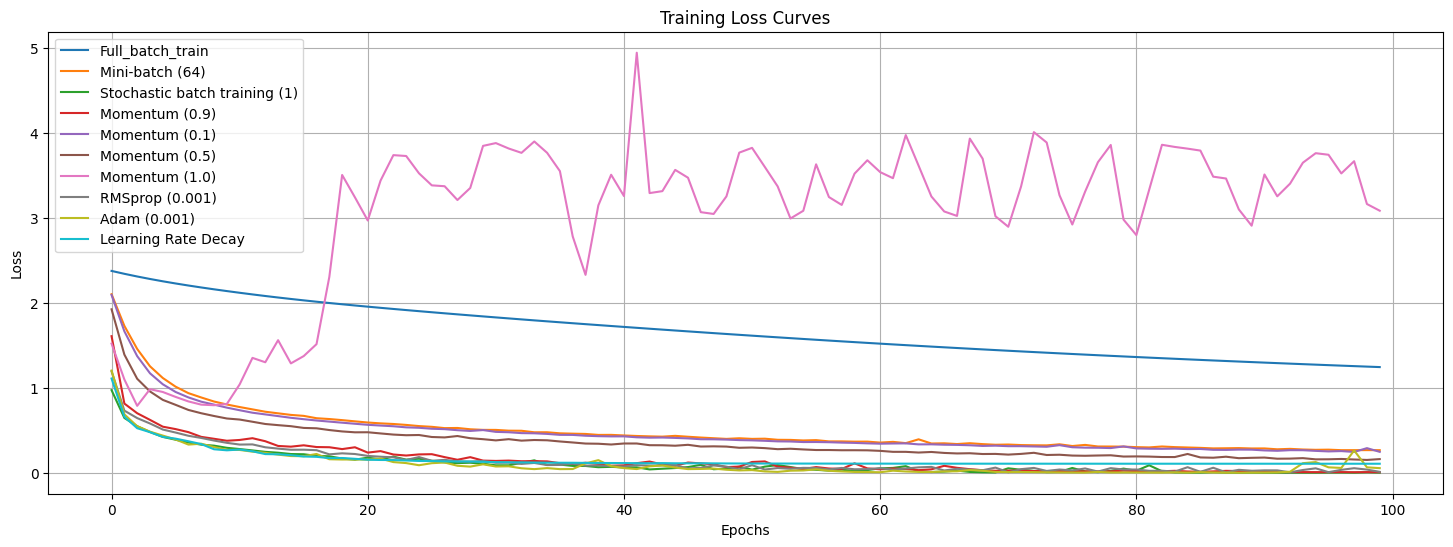

In [31]:
plt.figure(figsize= (18, 6))
for name in curves:
    if name in ("Raw_pixels_sgd", 'Normalized_pixels_sgd', 'RMSprop (0.1)'):
        continue

    plt.plot(curves[name], label=name)
plt.title('Training Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

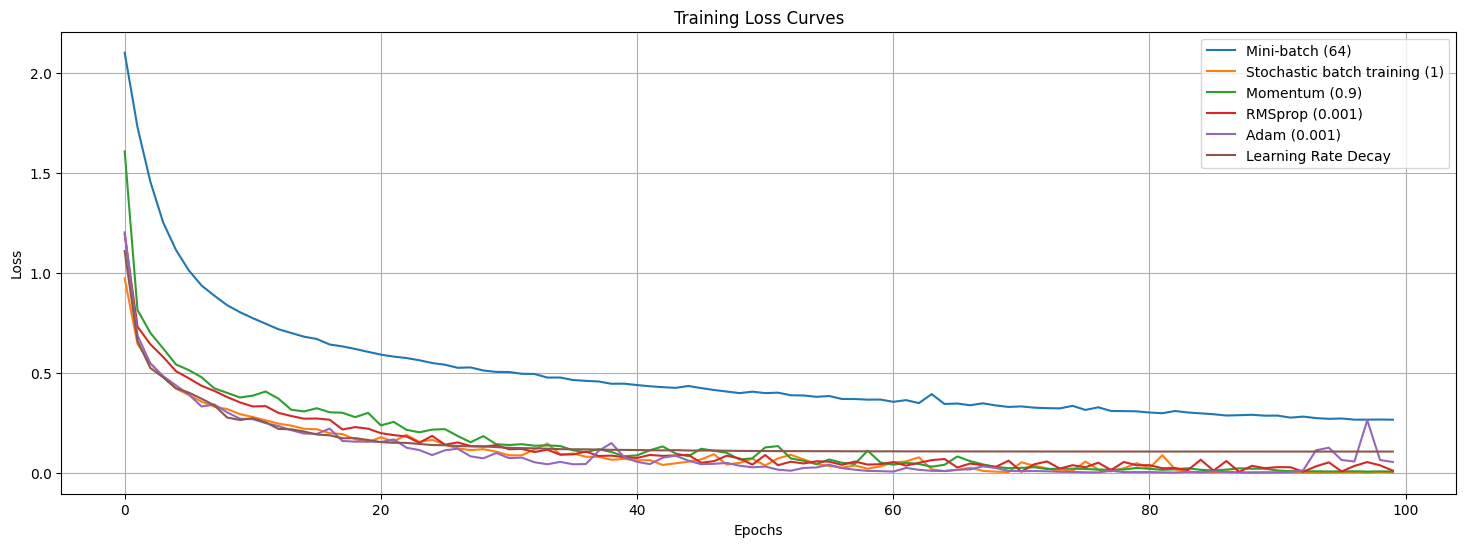

In [36]:
models = ['Mini-batch (64)', 'Stochastic batch training (1)', 'Momentum (0.9)', 
          'RMSprop (0.001)', 'Adam (0.001)', 'Learning Rate Decay']

plt.figure(figsize= (18, 6))
for name in models:
    plt.plot(curves[name], label=name)
plt.title('Training Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# This file is submitted by Shashank Goel.